In [1]:


import numpy as np

import scipy as sp 
import pylab as pl
#pl.rcParams['figure.figsize'] = , 16

from scipy.odr import Model, Data, ODR
from scipy.stats import linregress
import healpy as hp
def get_betas(xdat, xnoise, ydat, ynoise, v1, v2):
    """perform linear regression between two data set and get spectral index """

    mydata = Data(xdat, ydat, wd=xnoise**-2, we=ynoise**-2)
    myodr = ODR(mydata, Model(sform), beta0=[0.05, 0.5])
    myoutput = myodr.run()
    fitted_gradient = myoutput.beta[0]
    error_gradient = myoutput.sd_beta[0]

    ef = np.log(v2/v1)
    beta = np.log(fitted_gradient) / ef
    beta_error = error_gradient / (fitted_gradient * ef)

    #if beta > -2.1 or beta < -3.5:
    #    plt.plot(xdat, ydat, '.')
    #    plt.plot(xdat, fitted_gradient*xdat +  myoutput.beta[1], 'r-')
    #    plt.show()

    #    print("breaking here")
    
    return beta, beta_error, myoutput 
    
def sform(param, xxx):
    '''linear reggression'''
    return xxx * param[0] + param[1]
def fitting_beta_curvature(X, beta, cs):
   return beta*X +cs*X*X 

def sfunc(xxx, bval, cval):
    '''linear reggression'''
    return xxx * bval + cval

In [2]:
synch_emission = lambda nu,nu0,  I0, beta_s, cs, nup : I0 * (nu/nu0)**(beta_s + cs * np.log(nu/nup) )
free_emission = lambda nu,nu0, I0, beta :  I0 * (nu/nu0)**beta 

In [3]:

def rotate_map(mapin, coord_in , coord_out ) : 
    alm = hp.map2alm (mapin )
    R=  hp.Rotator(coord=[coord_in, coord_out ])
    alm =  R.rotate_alm (alm )
    map_out = hp.alm2map (alm , nside= hp.get_nside(mapin ))
    return map_out

## read validation maps 

In [4]:

from astropy import units as u, constants as const
maps={} 
mapserr={}
offerr={}

fstring="haslam408_ds_Remazeilles2014.fits"

try :
    print(f"reading {fstring} ")

    maps[408],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/{fstring}", out ="../lwa_data")
    maps[408]=  hp.read_map(f"../lwa_data/{fstring}"  )


maps[408]= (maps[408]*u.K -8.9*u.K )
mapserr[408] = np.sqrt((0.1 * maps[408].value)**2 + 1.3**2) /  maps[408].value # 10 per cent for 408 calibration plus the 1.3K offset error
offerr[408] = 0.0 # it has already been added to maperr


fstring='Dwingeloo_Kelvins_1_256.fits' 

try :
    print(f"reading {fstring} ")
    maps[820],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/dwingeloo_820/{fstring}", out ="../lwa_data")
    maps[820]=  hp.read_map(f"../lwa_data/{fstring}"  )
nans= maps[820]<0 
maps[820][nans]=np.nan
maps[820] =(maps[820]*u.K)
mapserr[820] = 0.05 # 5 per cent for 150 calibration
offerr[820] = 0.0




fstring="lambda_23de_hea.fits"
 
try :
    print(f"reading {fstring} ")
    maps[2326]=  hp.read_map(filename=f"../lwa_data/{fstring}"   )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/rhodes_2326/{fstring}" , out ="../lwa_data")
    maps[2326]=  hp.read_map(f"../lwa_data/{fstring}"  )
maps[2326] = rotate_map(maps[2326], 'C', 'G')
zeros = maps[2326]< 0.027 
maps[2326][zeros] = np.nan
maps[2326]= (maps[2326]*u.K   )
offerr[2326] = 0.0
mapserr[2326 ] = 0.05

fstring="spass_dr1_1902_healpix_Tb.i.fits"
try :
    print(f"reading {fstring} ")
    maps[2300]=  hp.read_map(filename=f"../southern_data/{fstring}")  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/spass/{fstring}" , out ="../southern_data")
    maps[2300]=  hp.read_map(f"../southern_data/{fstring}")  
nans =maps[2300] <-1e20 
maps[2300][nans] = np.nan
maps[2300]= (maps[2300]*u.K   )
offerr[2300] = 0.0
mapserr[2300] = 0.05

fstring="quijote_mfi_smth_skymap_11ghz_512_dr1.fits"
try :
    print(f"reading {fstring} ")
    maps[11000]=  hp.read_map(filename=f"../lwa_data/{fstring}"   )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/suborbital/QUIJOTE/QUIJOTE-MFI-Release1/{fstring}" , out ="../lwa_data")
    maps[11000]=  hp.read_map(f"../lwa_data/{fstring}"  )

nans = maps[11000] < -1e20
maps[11000][nans] = np.nan
maps[11000] =(maps[11000]*u.mK).to(u.K )  
offerr[11000] = 0.0
mapserr[11000] = 0.05

fstring ="EDA2_159MHz_I_noPrior_HPXbin.fits"
try :
    print(f"reading {fstring} ")

    maps[159],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/EDA2/{fstring}", out ="../lwa_data")
    maps[159]=  hp.read_map(f"../lwa_data/{fstring}"  )
maps[159] = rotate_map(maps[159], 'C', 'G')
disc = hp.query_disc(hp.get_nside(maps[159]), hp.ang2vec ( theta=np.pi/3,phi=2./3*np.pi ) , radius= np.radians(40 )  )
maps[159][disc]= np.nan  

maps[159] = (maps[159] * u.K )
mapserr[159] = 0.05 # 5 per cent for 150 calibration
offerr[159] = 0.0




reading haslam408_ds_Remazeilles2014.fits 
reading Dwingeloo_Kelvins_1_256.fits 
reading lambda_23de_hea.fits 
reading spass_dr1_1902_healpix_Tb.i.fits 
reading quijote_mfi_smth_skymap_11ghz_512_dr1.fits 
reading EDA2_159MHz_I_noPrior_HPXbin.fits 


In [5]:



offerr={}
off_map = {} 
offsetvals = {} 

offsetvals = {}
def remove_off(map, hasmap, maperr, haserr  ):
    nside_superpix=8
    nan1 =~np.ma.masked_invalid (map).mask 
    npix = map.size 
    pixs = np.arange(npix)
    super_nans = hp.ud_grade(nan1.astype('int'), nside_out=nside_superpix).astype('bool') 
    super_pixs = np.arange(super_nans.size ) [super_nans] 
     
    offsets = np.zeros_like(super_pixs  )*1. 
    offmap = np.full(hp.nside2npix(nside_superpix), np.nan)     
    nansize =0 

    for jj, ipix in enumerate(super_pixs ) : 

        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map [ipix] =1
        

        patch =  (hp.ud_grade(super_map, nside_out=hp.get_nside(map))) .astype('bool')
     
        try:
            
            errx = haserr[patch] * hasmap[patch]
            erry =  maperr * map[patch]
            mydata = Data(hasmap[patch], map[patch], wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]
            if np.corrcoef(hasmap[patch].value, map[patch].value)[0,1] > 0.75:
                offsets[jj] = cfit
            else:
                offsets[jj] = np.nan
        except  ValueError: 
            nansize+=1 
            offsets[jj]= np.nan 

    offmap[super_pixs] = offsets

    #avec = np.nanmean( offsets ) *map.unit
    avec = np.nanmedian( offsets ) *map.unit
    map = map - avec
    
    return map, avec  , np.nanstd(offsets) /np.sqrt(offsets.size - nansize), offmap 

for k in maps.keys():
    if k ==408 : continue
    tmp= hp.ud_grade( maps[k].value  , nside_out= hp.get_nside(maps[408]) )  *maps[k].unit
    tmp[tmp.value <-1e20]= np.nan 
    tmp, offsetvals[k], offerr[k], off_map[k] = remove_off(tmp, maps[408], mapserr[k], mapserr[408])
    maps[k][maps[k].value <-1e20]= np.nan
    
    maps[k] = maps[k] - offsetvals[k] 
    
    print(f" {k} MHz data estimated offset: {offsetvals[k]:.4f} ± {offerr[k]:.4f}")


 820 MHz data estimated offset: 4.4422 K ± 0.0795
 2326 MHz data estimated offset: -0.0609 K ± 0.0118
 2300 MHz data estimated offset: -0.0166 K ± 0.0163
 11000 MHz data estimated offset: -0.0078 K ± 0.0057
 159 MHz data estimated offset: 98.3009 K ± 3.1417


## build frefree template 

reading COM_CompMap_freefree-commander_0256_R2.00.fits 
reading EM_mean_std.fits 


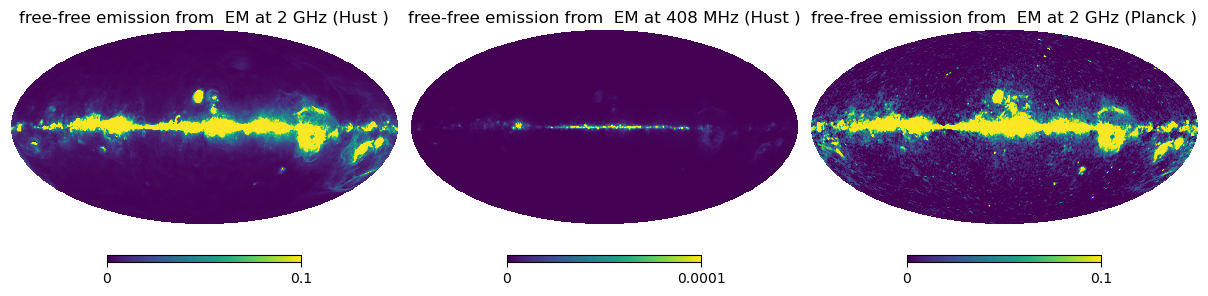

In [6]:
fstring="COM_CompMap_freefree-commander_0256_R2.00.fits"
try :
    print(f"reading {fstring} ")
    tmp=  hp.read_map(filename=f"../lwa_data/{fstring}" ,field= ['EM_ML', 'TEMP_ML']  )  
except FileNotFoundError: 
    filename = wget.download( f"http://pla.esac.esa.int/pla/aio/product-action?MAP.MAP_ID=COM_CompMap_freefree-commander_0256_R2.00.fits" , out ="../lwa_data")
    tmp=  hp.read_map(f"../lwa_data/{fstring}" ,field= ['EM_ML', 'TEMP_ML']  )
 
planck_em = tmp[0]* u.cm**-6 *u.pc
planck_te = tmp [1]*u.K 

fstring = "EM_mean_std.fits"
try :
    print(f"reading {fstring} ")
    hust=  hp.read_map(filename=f"../lwa_data/{fstring}"   )  
except FileNotFoundError: 
    filename = wget.download( f"https://zenodo.org/records/10523170/files/EM_mean_std.fits" , out ="../lwa_data")
    hust =  hp.read_map(f"../lwa_data/{fstring}"    )
hust *= u.cm**-6 *u.pc

Tff = lambda Te , nu,EM  : Te * (1.0 - np.exp(-tauff(Te,nu, EM ))) 
tauff = lambda Te,nu , EM : 0.05468 *   (Te.value )**-1.5 * (nu.value )**-2 *EM.value   *gff (Te,nu) 
Zi =1 
gff =lambda Te ,nu :  np.log (np.exp(1.0) +np.exp (5.960 -np.sqrt(3)/np.pi *np.log (Zi *nu.to(u.GHz).value *(Te/(1e4*u.K)  )**-1.5  )) )  

freefree_0h = Tff(Te=planck_te, nu=(2*u.GHz), EM=hust   )
freefree_408 = Tff(Te=planck_te, nu=(408*u.MHz), EM=hust   )

freefree_0p = Tff(Te=planck_te, nu=(2*u.GHz), EM=planck_em   )
pl.figure(figsize=(12,6))
hp.mollview(freefree_0h , title="free-free emission from  EM at 2 GHz (Hust )" , sub=131, min=0,max=.1)
hp.mollview(freefree_408, title="free-free emission from  EM at 408 MHz (Hust )" , sub=132, min=0,max=.0001)
hp.mollview(freefree_0p , title="free-free emission from  EM at 2 GHz (Planck )" ,sub=133 , min=0,max=.1)

## build emission model

In [34]:
model ={} 

synchro_nu0 =408 *u.MHz
freefree_nu0 = 408* u.MHz 
label='fine' 
freefree_0h = Tff(Te=planck_te, nu=(freefree_nu0), EM=hust   )
for fr,m in maps.items():
    if fr==408 :continue 
    nside=hp.get_nside(m )


    beta_s =hp.ud_grade(np.load(f'../outputs/fgbuster_filled_maps_nside{64}_{label}.npz') ["Synchrotron.beta_pl"] , nside_out=nside)
    cs = hp.ud_grade(np.load(f'../outputs/fgbuster_filled_maps_nside{64}_{label}.npz') ["Synchrotron.running"] , nside_out=nside)
    up = hp.ud_grade(np.load(f'../outputs/fgbuster_filled_maps_nside{64}_{label}.npz') ["Synchrotron.nu_pivot"] , nside_out=nside)  
    beta_f = hp.ud_grade(np.load(f'../outputs/fgbuster_filled_maps_nside{64}_{label}.npz') ["FreeFree.beta_pl"] , nside_out=nside)  
    iref= hp.ud_grade( maps[synchro_nu0.value].value  , nside_out=nside)  

    iref_f= hp.ud_grade( freefree_0h.value   , nside_out=nside) 
    
    model[fr] = ( free_emission( fr  ,freefree_nu0.value , iref_f, beta_f  ) + synch_emission( fr ,synchro_nu0.value , iref, beta_s, cs, up   )) *u.K




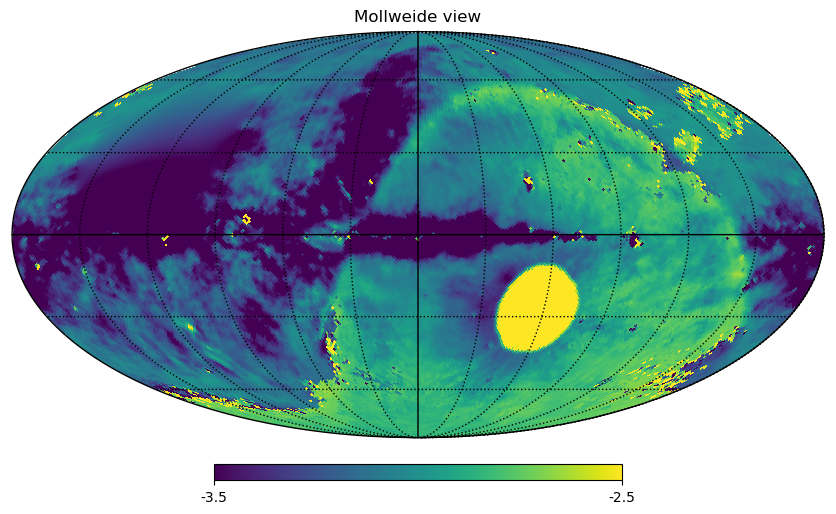

In [35]:
hp.mollview(beta_s, min=-3.5,max=-2.5) 
hp.graticule() 

[  159   408   820  2300  2326 11000]


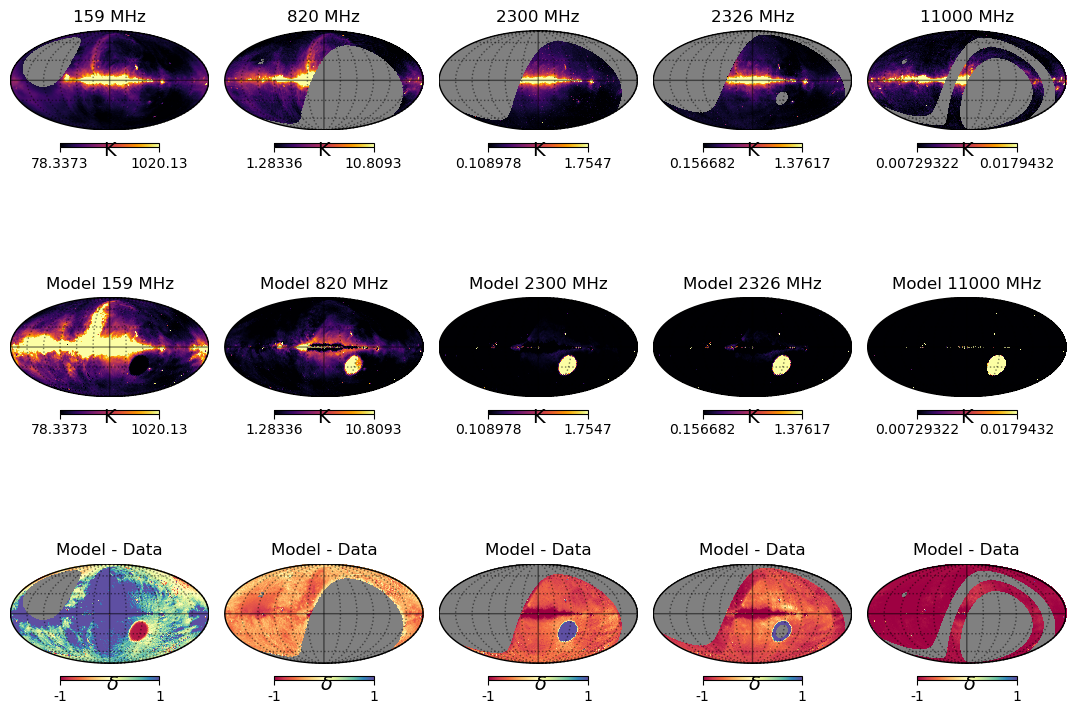

In [36]:
pl.figure(figsize=(15,8 )) 
freqs = np.sort ( list(maps.keys()) )    
print(freqs) 
j=0
for fr in freqs :
    if fr==408 :continue 
    tmp = maps[fr]
    mask =maps[fr].value  <-1e20 
    min = np.nanquantile(  tmp.value,0.05  )  
    max = np.nanquantile(  tmp.value,0.97  ) 
    
    nans = np.isnan(tmp.value)  

    hp.mollview( (tmp),  title=f'{fr} MHz'  , sub=(3,7,1+j) , notext=True ,min=min , max=max , cmap='inferno' ,unit='K')
    hp.mollview( (model[fr]   ),  title=f'Model {fr} MHz'  , sub=(3,7,8+j) , notext=True ,cmap='inferno' ,unit='K',min=min , max=max  )
    hp.mollview(    (model[fr] - tmp) / tmp   ,  unit=r' $\delta $ '   , title ='Model - Data' , sub=(3,7,15+j) , notext=True ,min=- 1 , max=1 , cmap= 'Spectral'    )
    
    j+=1
hp.graticule(alpha=.5 ) 


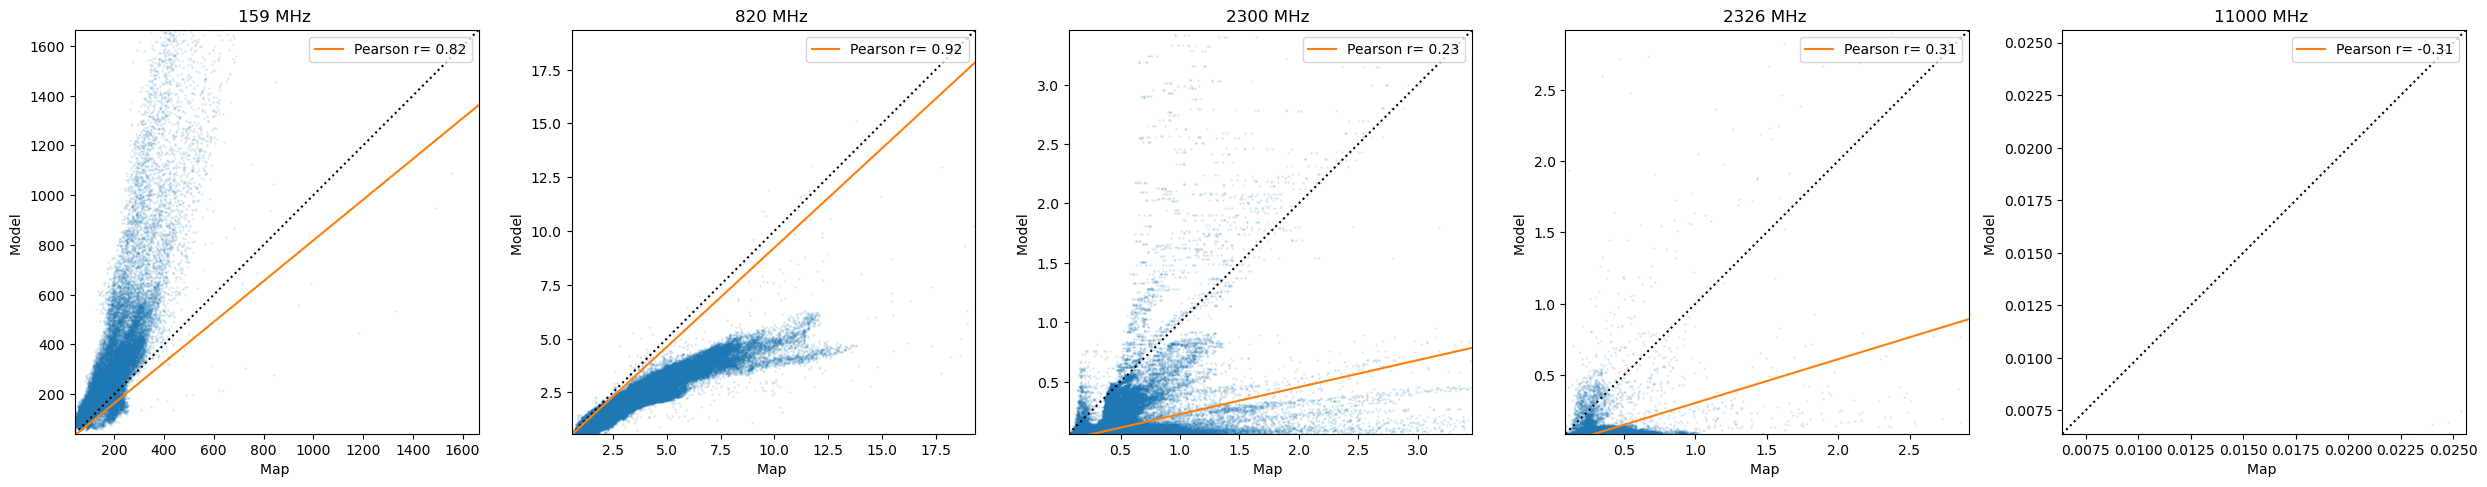

In [13]:
j=0
pl.figure (figsize=(25,5) )
for fr in freqs :
    if fr==408 :continue 
    m = maps[fr] .copy () 
    strip =hp.query_strip(nside= hp.get_nside(m), theta1= np.radians(80), theta2= np.radians(100) )
 
    m[strip]    =np.nan 
    
    min = np.nanquantile(  m.value,0.0001 )  
    max = np.nanquantile(  m.value,0.9999  ) 
    nans = np.isnan(m.value)  

    ax = pl.subplot(1,5,1+j)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(min,    max)
    ax.set_ylim(min,   max)
    ax.set_ylabel('Model ')
    ax.set_xlabel('Map ')
    ax.set_title ( f'{fr} MHz ' )
    r, p = sp.stats.pearsonr(x=m[~nans].value, y=model[fr][~nans].value )

    ax.scatter ( m [~nans ], model[fr] [~nans ] , s=1 , alpha=0.1 )
    ax.plot ( [min,max],[min,max    ] ,'k:',      )
    ax.plot ( [min,max],r*np.array([min,max    ] ) ,'C1',    label = f"Pearson r= {r:.2f}" )
    ax.legend(loc='upper right' )
    j+=1
pl.tight_layout()

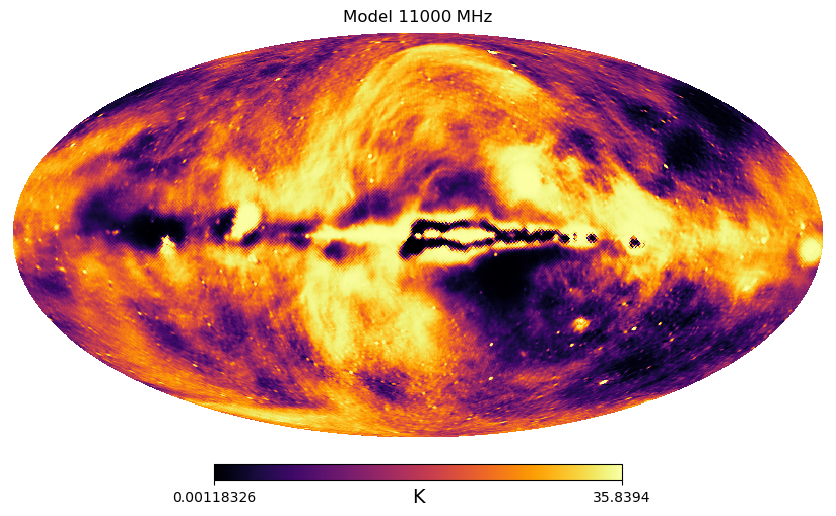

In [15]:
hp.mollview( (model[2300]   ),  title=f'Model {fr} MHz'  ,  notext=True ,cmap='inferno' ,unit='K', norm='hist' ) 

northern survey
0.9053012114901207 64
0.9188589939768805 64
0.75777240184223 64
0.46397764537823005 64
northern survey
0.9703551682488016 1024
0.9727822654291567 1024
0.7553000704015033 1024
0.7030369912968996 1024
southern survey
0.8208757377010413 16384
0.21076523118747514 16384
0.15920857049957693 16384
0.24260208020367835 16384
southern survey
0.908404998387223 1024
0.4813107058445037 1024
-0.15089715338548138 1024
0.35232229902223045 1024
northern survey
0.9016463248708269 1893
0.42474386570477296 4096
0.12373359095090705 4096
0.3556718872723316 4096


<Figure size 2500x500 with 0 Axes>

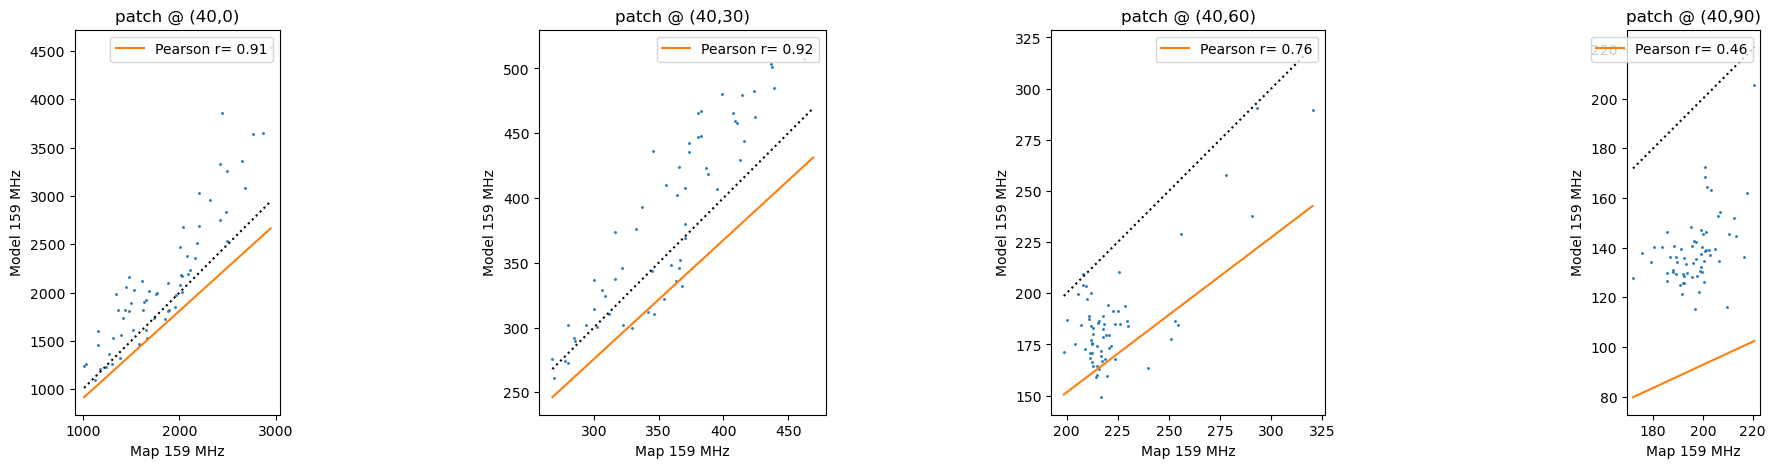

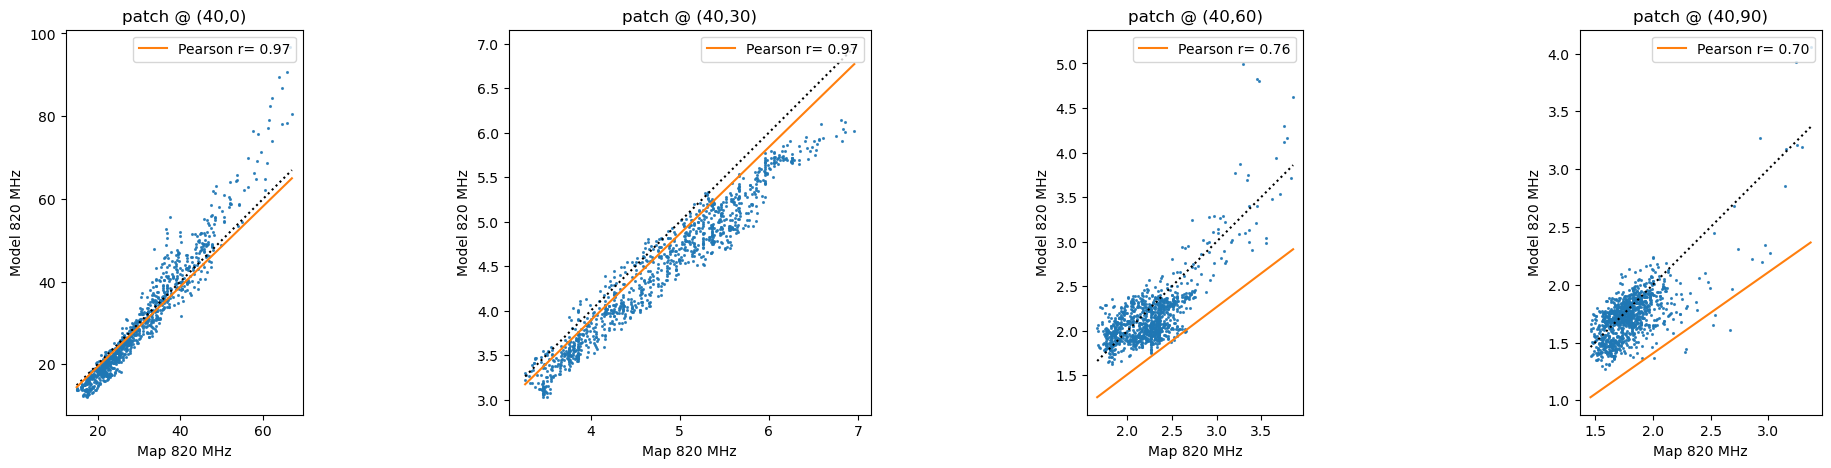

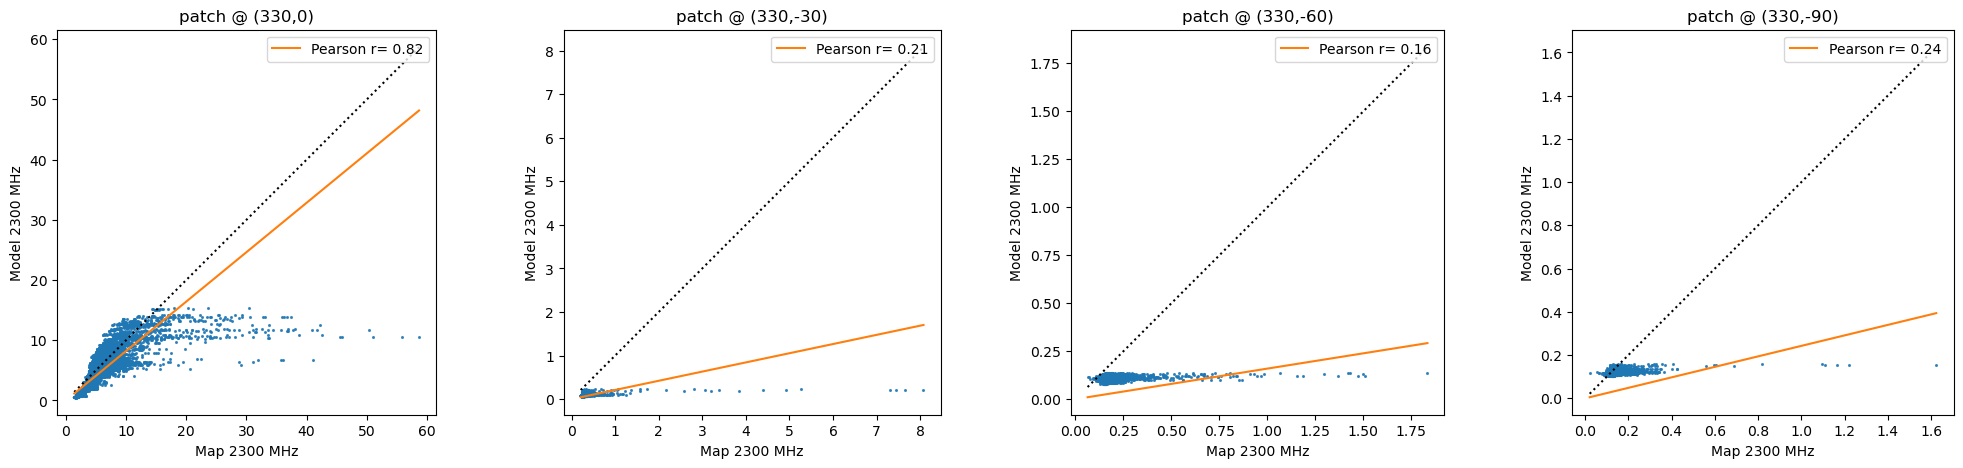

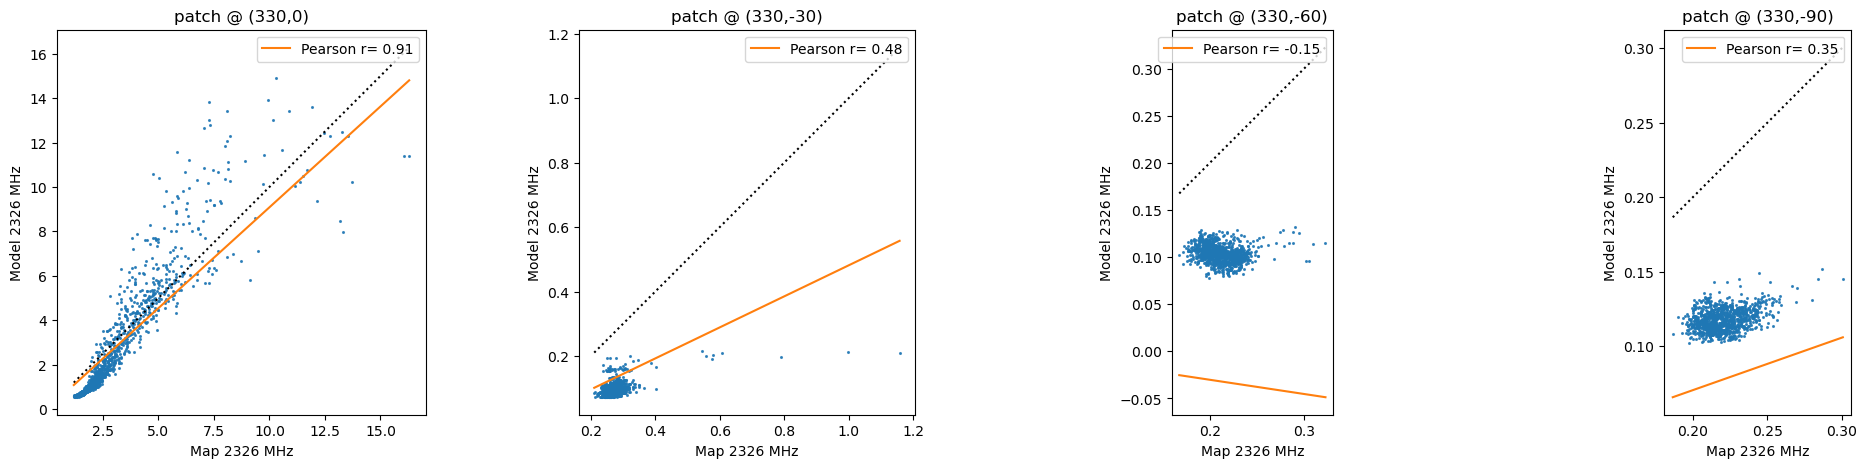

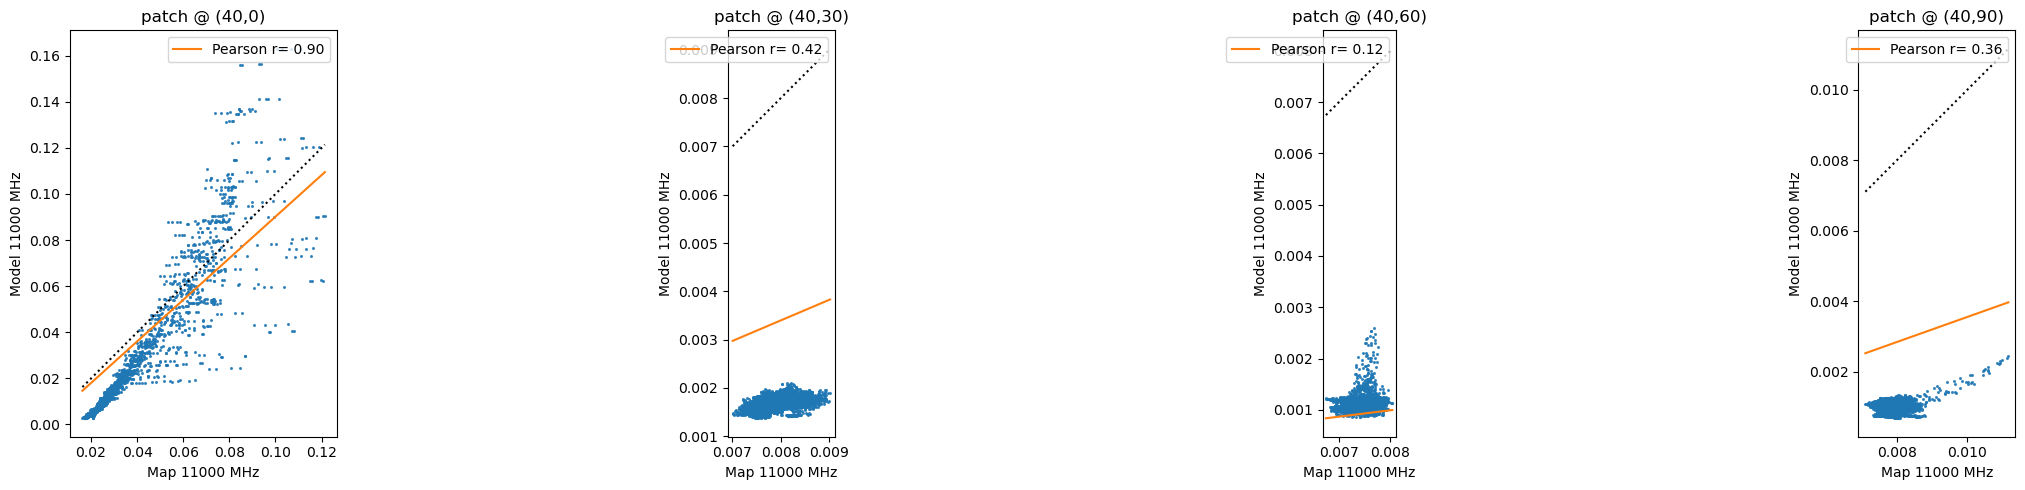

In [75]:
j=0
pl.figure (figsize=(25,5) )
nside_large=8
for fr in freqs :
    if fr==408 :continue 
    pl.figure (figsize=(25,5) )
    m = maps[fr] .copy () 
    if np.isnan(m[0]):
        print('southern survey') 
        coords = np.vstack([(330 , 0  ), (330 , -30 ) ,(330 , -60  ),  (330, -90   )]) 
    else:
        print('northern survey') 

        coords = np.vstack([(40 , 0  ), (40 , 30 ) ,(40 , 60  ),  (40, 90   )])

    ipixs = hp.ang2pix(nside=nside_large, theta= coords[:,0], phi= coords[:,1], lonlat=True  )

    
    for jj, ip in enumerate(ipixs):
        patches = np.full(hp.nside2npix(nside_large), fill_value=0  ) 

        ax = pl.subplot(1,coords.shape[0],1+jj)

        patches[ip] =1 
        mask = np.logical_and(hp.ud_grade(patches, nside_out= hp.get_nside(m) ).astype('bool'), ~np.isnan(m.value))
        #hp.mollview(mask*m  )
        min = np.min(  m[mask].value )  
        max = np.max (  m[mask].value   ) 

        ax.set_aspect('equal', adjustable='box')
        #ax.set_xlim(min,    max)
        #ax.set_ylim(min,   max)
        ax.set_ylabel(f'Model {fr} MHz')
        ax.set_xlabel(f'Map {fr} MHz')
        ax.set_title ( f'patch @ ({coords[jj,0]},{coords[jj,1]})' )
        r  = np.corrcoef(x=m[mask].value, y=model[fr][mask].value )[0,1]
        print(r  , mask.sum () )
        ax.scatter ( m [mask ].value, model[fr] [mask ].value , s=1.5 , alpha=0.8 )
        ax.plot ( [min,max],[min,max    ] ,'k:',      )
        ax.plot ( [min,max],r*np.array([min,max    ] ) ,'C1',    label = f"Pearson r= {r:.2f}" )
        ax.legend(loc='upper right' )
pl.tight_layout()

northern survey
(4, 2)
[ 0  4 41 89]


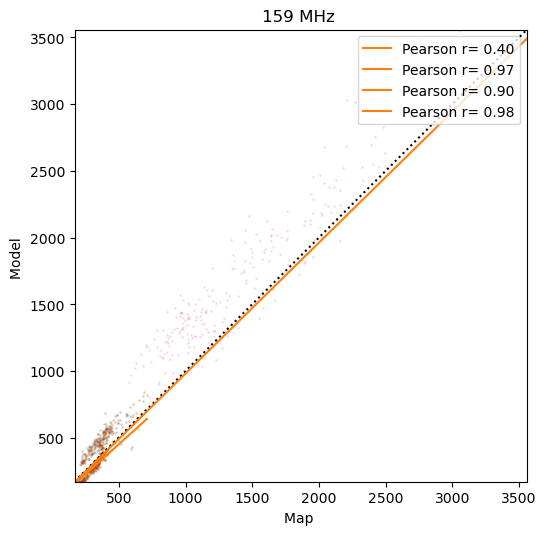

In [ ]:
j=0
pl.figure (figsize=(25,5) )
nside_large=4 
for fr in freqs :
    if fr==408 :continue 
    pl.figure (figsize=(25,5) )
    m = maps[fr] .copy () 
    if np.isnan(m[0]):
        print('southern survey') 
        coords = np.vstack([(11.*np.pi/6,np.pi/2), (11.*np.pi/6, 4*np.pi/6) ,(11.*np.pi/6, 5*np.pi/6 ),  (11/6.*np.pi, np.pi  )]) 
    else:
        print('northern survey') 

        coords = np.vstack([(np.pi/6, 0. ),(np.pi/6, np.pi/6) ,(np.pi/6, np.pi/3), (np.pi/6, np.pi/2  )])
    print(coords.shape )
    ax = pl.subplot(coords.shape[0] ,3,1+j)

    ipixs = hp.ang2pix(nside=nside_large, phi= coords[:,0], theta= coords[:,1] )
    print(ipixs)

    patches = np.zeros(hp.nside2npix(nside_large)) 
    for jj, ip in enumerate(ipixs):

        patches[ip] =1 
        mask = hp.ud_grade(patches, nside_out= hp.get_nside(m) ).astype('bool') 
        min = np.quantile(  m[mask].value,0.0001 )  
        max = np.quantile(  m[mask].value,0.9999  ) 

 

        ax = pl.subplot(1,5,1+j)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(min,    max)
        ax.set_ylim(min,   max)
        ax.set_ylabel('Model ')
        ax.set_xlabel('Map ')
        ax.set_title ( f'{fr} MHz ' )
        r, p = sp.stats.pearsonr(x=m[mask].value, y=model[fr][mask].value )

        ax.scatter ( m [mask ].value, model[fr] [mask ].value , s=1 , alpha=0.5 )
        ax.plot ( [min,max],[min,max    ] ,'k:',      )
        ax.plot ( [min,max],r*np.array([min,max    ] ) ,'C1',    label = f"Pearson r= {r:.2f}" )
        ax.legend(loc='upper right' )
    j+=1
    break 
pl.tight_layout()

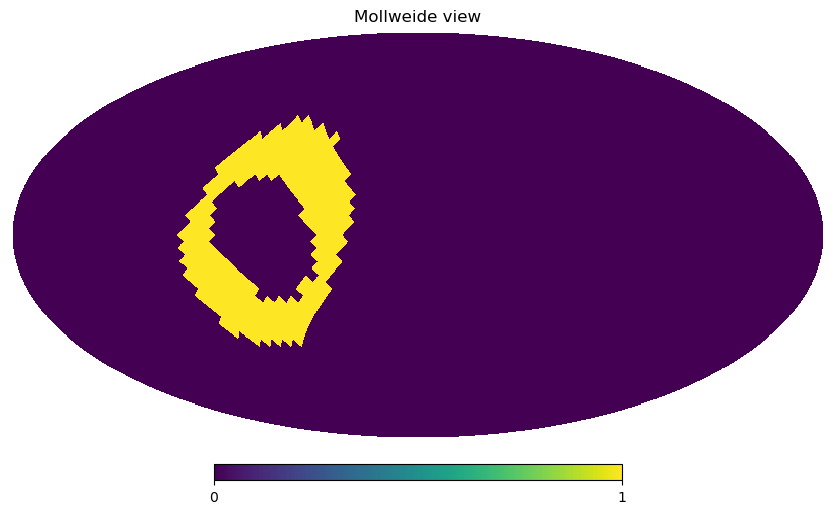

In [10]:
from pathlib import Path
import wget 
arcadefile = Path("../inputmaps/arc2_3150_v19.fits")

if not arcadefile.exists():
    wget.download( f" https://lambda.gsfc.nasa.gov/data/suborbital/ARCADE/arc2_3150_v19.fits", out ="../inputmaps")
     

arcade = hp.read_map(arcadefile)
mask = arcade != 0
mask_arcade = hp.ud_grade(mask, nside_out=hp.get_nside(cs ))
hp.mollview(mask_arcade)

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_33997/2118938279.py:17: SyntaxWarning: invalid escape sequence '\p'
  f" Kogut 2012 measured Cs = -0.052\pm 0.005, we get within ARCADE patch:\n"
/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_33997/2118938279.py:18: SyntaxWarning: invalid escape sequence '\p'
  + f"{cs[mask_arcade].mean():.4f}\pm { cs[mask_arcade] .std():.4f}"
/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_33997/2118938279.py:2: RuntimeWarning: invalid value encountered in divide
  (cs * mask_arcade) / mask_arcade,
/var/folders/2y/7mtx094j2tb45h4cj42hcw8w0000gp/T/ipykernel_33997/2118938279.py:12: RuntimeWarning: invalid value encountered in divide
  hp.mollview((cs*mask_arcade ) /mask_arcade, title="synchrotron curvature", cmap="jet", m

 Kogut 2012 measured Cs = -0.052\pm 0.005, we get within ARCADE patch:
-0.0855\pm 0.0406


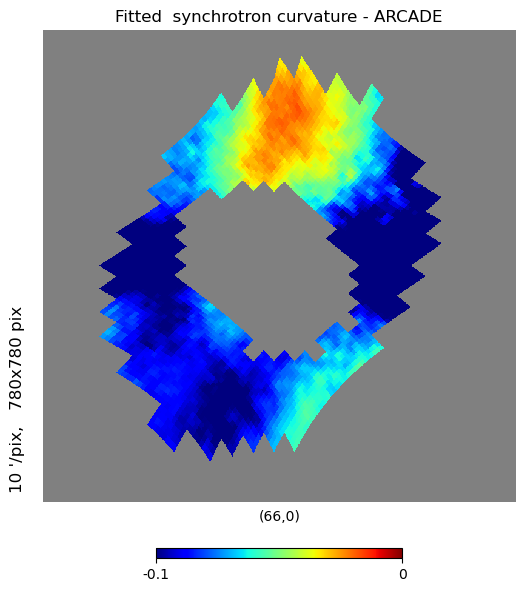

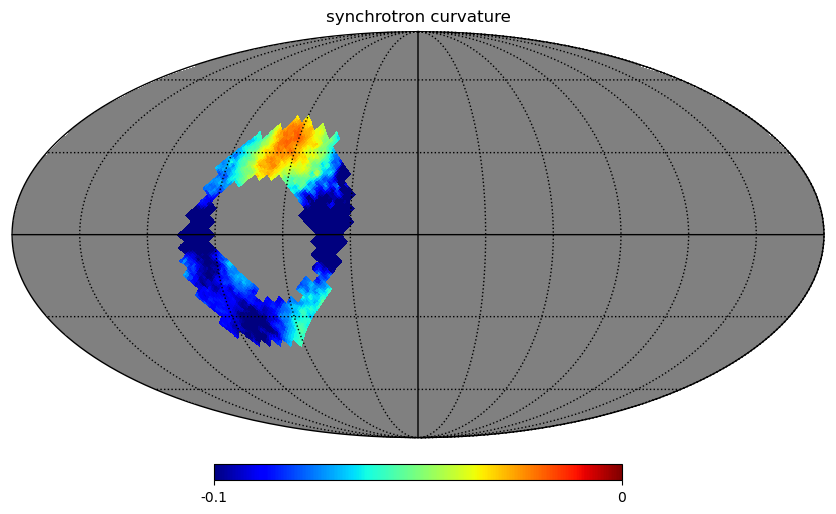

In [18]:
hp.gnomview(
    (cs * mask_arcade) / mask_arcade,
    title="Fitted  synchrotron curvature - ARCADE",
    rot=[66, 0],
    reso=10,
    xsize=780,
    cmap="jet",
    min=-0.1,
    max=0,
)

hp.mollview((cs*mask_arcade ) /mask_arcade, title="synchrotron curvature", cmap="jet", min=-0.1, max=0)
hp.graticule()
     

print(
    f" Kogut 2012 measured Cs = -0.052\pm 0.005, we get within ARCADE patch:\n"
    + f"{cs[mask_arcade].mean():.4f}\pm { cs[mask_arcade] .std():.4f}"
)